# Zambia's heat extremes: the signal rainfall didn't show

**Question.** The companion [rainfall analysis](https://github.com/nephatmwanza/zambia-rainfall-extremes) found that Zambia's rainy season has
*reorganised* over 1981–2025 — more wet days, weaker downpours, longer dry spells — but shows
no trend that survives multiple-testing control. Not one grid cell, for any rainfall index.
Does temperature behave the same way, or is it different?

This notebook runs **the same test, over the same country, the same 45 years, and the same
baseline** — changing only the variable. That makes the comparison a like-for-like one
rather than an artefact of different choices.

**Data.** ERA5 daily maximum temperature, 0.25°, clipped to Zambia. Annual (calendar-year)
indices plus the ONDJFM growing season used by the rainfall analysis.

| Index | Meaning | Units |
|---|---|---|
| `txm` | mean daily maximum temperature | °C |
| `txx` | hottest day of the period | °C |
| `tx90p` | share of days above the calendar-day 90th percentile | % of days |
| `su35` | days above 35 °C | days |
| `wsdi` | warm-spell days: ≥6 consecutive days above the 90th percentile | days |

**A detail that matters.** `tx90p` and `wsdi` are defined against the 90th percentile of
1991–2020 computed **separately for each calendar day**, on a 5-day window (ETCCDI). Zambia's
mean daily maximum runs ~25 °C in July and ~31 °C in October, so a single fixed threshold
would flag most of the hot season and almost none of the cool season. Computed in
`scripts/06_compute_heat_indices.sh`.

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import netCDF4 as nc
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

ROOT = os.getcwd()
if os.path.basename(ROOT) == "notebooks":
    ROOT = os.path.dirname(ROOT)
sys.path.insert(0, os.path.join(ROOT, "src"))
FIGDIR = os.path.join(ROOT, "figures"); os.makedirs(FIGDIR, exist_ok=True)

from trends import mk_sen, bh_fdr, selftest
print("repo root:", os.path.basename(ROOT))

repo root: Zambia_Temperature_Extremes


## Method

Identical to the rainfall analysis: **Mann–Kendall** for the test, **Theil–Sen** for the
magnitude, tie correction for integer-valued indices, the Hamed & Rao serial-correlation
correction constrained so it can only *inflate* variance, and Benjamini–Hochberg
false-discovery-rate control across grid cells.

The implementation lives in `src/trends.py`, shared verbatim with the [rainfall
analysis](https://github.com/nephatmwanza/zambia-rainfall-extremes) so the two studies cannot drift apart. It was verified to reproduce that
study's published trends to floating-point precision. The calibration self-test runs below —
an uncalibrated test would invalidate every *p*-value in this notebook.

In [2]:
selftest()

trends.selftest passed | false-positive rate on white noise: 4.75% (nominal 5%) | median variance inflation 1.000


4.75

In [3]:
# ---- design tokens: identical to the rainfall notebook ------------------------
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE, SLOT1 = "#e1e0d9", "#c3c2b7", "#fcfcfb", "#2a78d6"

# Sequential = ONE hue light->dark. Heat uses a warm ramp, deliberately distinct from the
# blue used for rainfall so the two analyses are never confused at a glance.
SEQ_WARM = LinearSegmentedColormap.from_list("seq_warm", [
    "#fdf0e3", "#fbdcc0", "#f7c49b", "#f2a878", "#e88b5c", "#db6e46",
    "#c85338", "#ad3e2e", "#8e2c26", "#6b1d1d"])
# Diverging, gray midpoint, equal arms - blue = cooler, red = warmer
DIV_RB = LinearSegmentedColormap.from_list("div_rb", [
    "#0d366b", "#256abf", "#3987e5", "#86b6ef", "#cde2fb",
    "#f0efec",
    "#f7c9c8", "#e88b8a", "#d03b3b", "#a82c2c", "#6b1717"])

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans"],
    "text.color": INK, "axes.labelcolor": INK2,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": AXIS, "axes.linewidth": .8,
    "grid.color": GRID, "grid.linewidth": .8, "grid.linestyle": "-",
    "axes.grid": False, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9, "axes.titlesize": 10, "figure.dpi": 110, "savefig.dpi": 160,
})

IDX  = ["txm", "txx", "tx90p", "su35", "wsdi"]
UNIT = {"txm": "°C", "txx": "°C", "tx90p": "% of days", "su35": "days", "wsdi": "days"}
LAB  = {"txm": "TXm (mean daily max)", "txx": "TXx (hottest day)",
        "tx90p": "TX90p (days above 90th pct)", "su35": "SU35 (days above 35°C)",
        "wsdi": "WSDI (warm-spell days)"}
print("tokens ready")

tokens ready


## Province and national trends

In [4]:
ann = pd.read_csv(os.path.join(ROOT, "data/processed/zambia_heat_annual_by_province.csv"))
sea = pd.read_csv(os.path.join(ROOT, "data/processed/zambia_heat_ondjfm_by_province.csv"))
years = np.sort(ann.year.unique()).astype(float)
print(f"{len(years):.0f} years: {years.min():.0f}-{years.max():.0f}")

def trend_table(df, col, indices):
    rows = []
    for idx in indices:
        piv = df[df["index"] == idx].pivot(index=col, columns="region",
                                           values="value").sort_index()
        r = mk_sen(piv.values, np.sort(df[col].unique()).astype(float))
        for k, reg in enumerate(piv.columns):
            rows.append(dict(region=reg, index=idx, units=UNIT[idx],
                             mean=r["mean"][k],
                             trend_per_decade=r["slope_per_decade"][k],
                             p=r["p"][k], p_raw=r["p_raw"][k],
                             sig05=r["p"][k] < 0.05, sig10=r["p"][k] < 0.10))
    return pd.DataFrame(rows)

t_ann = trend_table(ann, "year", IDX)
t_sea = trend_table(sea, "season_start_year", ["txm", "txx", "tx90p", "su35"])
t_ann.to_csv(os.path.join(ROOT, "data/processed/trends_heat_annual_by_province.csv"), index=False)
t_sea.to_csv(os.path.join(ROOT, "data/processed/trends_heat_ondjfm_by_province.csv"), index=False)

nat = (t_ann[t_ann.region == "Zambia"].set_index("index")
       .loc[IDX, ["mean", "units", "trend_per_decade", "p", "sig05"]]
       .round({"mean": 2, "trend_per_decade": 3, "p": 4}))
nat.index = [LAB[i] for i in nat.index]
nat.columns = ["mean", "units", "trend/decade", "p", "p<0.05"]
nat

45 years: 1981-2025


,mean,units,trend/decade,p,p<0.05
TXm (mean daily max),27.46,°C,0.113,0.0390,True
TXx (hottest day),35.47,°C,0.348,0.0000,True
TX90p (days above 90th pct),9.92,% of days,0.724,0.1866,False
SU35 (days above 35°C),8.79,days,2.118,0.0000,True
WSDI (warm-spell days),8.97,days,-0.186,0.8068,False


In [5]:
print("PROVINCES SIGNIFICANT AT p<0.05, and direction of the trend (annual)")
print("-" * 78)
print(f"{'index':<32}{'increasing':>12}{'significant':>13}")
for idx in IDX:
    s = t_ann[(t_ann["index"] == idx) & (t_ann.region != "Zambia")]
    print(f"{LAB[idx]:<32}{int((s.trend_per_decade>0).sum()):>7}/10{int(s.sig05.sum()):>10}/10")

print("\nGROWING SEASON (ONDJFM), national")
print("-" * 78)
for _, r in t_sea[t_sea.region == "Zambia"].iterrows():
    v = "significant" if r.p < 0.05 else ("marginal" if r.p < 0.10 else "not significant")
    print(f"  {LAB[r['index']]:<32}{r.trend_per_decade:+8.3f} {r.units:<10} p={r.p:.4f}  {v}")

PROVINCES SIGNIFICANT AT p<0.05, and direction of the trend (annual)
------------------------------------------------------------------------------
index                             increasing  significant
TXm (mean daily max)                 10/10         4/10
TXx (hottest day)                    10/10        10/10
TX90p (days above 90th pct)          10/10         2/10
SU35 (days above 35°C)               10/10        10/10
WSDI (warm-spell days)                4/10         0/10

GROWING SEASON (ONDJFM), national
------------------------------------------------------------------------------
  TXm (mean daily max)              +0.078 °C         p=0.1678  not significant
  TXx (hottest day)                 +0.358 °C         p=0.0002  significant
  TX90p (days above 90th pct)       +0.566 % of days  p=0.4631  not significant
  SU35 (days above 35°C)            +1.577 days       p=0.0006  significant


## Maps

In [6]:
with open(os.path.join(ROOT, "boundaries/zambia_provinces_wgs84.geojson")) as f:
    PROV = json.load(f)

def basemap(ax):
    for feat in PROV["features"]:
        for ring in feat["geometry"]["coordinates"]:
            a = np.asarray(ring); ax.plot(a[:,0], a[:,1], lw=.6, color="#52514e", zorder=5)
    ax.set_xlim(21.5, 34.3); ax.set_ylim(-18.4, -8.0); ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)

src = nc.Dataset(os.path.join(ROOT, "data/processed/zambia_heat_annual.nc"))
lat = np.asarray(src.variables["lat"][:], float)
lon = np.asarray(src.variables["lon"][:], float)
mk = nc.Dataset(os.path.join(ROOT, "data/processed/zambia_province_mask_era5grid.nc"))
pmask = np.asarray(mk.variables["province_code"][:])
mlat, mlon = np.asarray(mk.variables["lat"][:], float), np.asarray(mk.variables["lon"][:], float)
mk.close()
# ERA5 stores latitude north-to-south while the masks run south-to-north; script 06 flips
# it at source. Assert rather than trust - a silent flip would mirror every province.
assert np.allclose(mlat, lat) and np.allclose(mlon, lon), "mask grid != index grid"
inside = pmask >= 1

dx, dy = lon[1]-lon[0], lat[1]-lat[0]
LON_E = np.append(lon-dx/2, lon[-1]+dx/2); LAT_E = np.append(lat-dy/2, lat[-1]+dy/2)

clim, gtrend, gp = {}, {}, {}
for idx in IDX:
    arr = np.asarray(np.ma.filled(src.variables[idx][:], np.nan), float)
    flat = arr.reshape(arr.shape[0], -1)
    ok = np.all(np.isfinite(flat), axis=0)
    sl = np.full(flat.shape[1], np.nan); pv = np.full(flat.shape[1], np.nan)
    if ok.any():
        r = mk_sen(flat[:, ok], years)
        sl[ok], pv[ok] = r["slope_per_decade"], r["p"]
    gtrend[idx] = np.where(inside, sl.reshape(len(lat), len(lon)), np.nan)
    gp[idx]     = np.where(inside, pv.reshape(len(lat), len(lon)), np.nan)
    clim[idx]   = np.where(inside, np.nanmean(arr, axis=0), np.nan)
    okc = np.isfinite(gp[idx]); sig = (gp[idx] < .05) & okc
    disc, _ = bh_fdr(gp[idx][okc], .10)
    print(f"  {idx:<6} median {np.nanmedian(gtrend[idx]):+7.3f} {UNIT[idx]:<10}"
          f" | {100*sig.sum()/okc.sum():5.1f}% cells p<0.05 | {int(disc.sum()):4d} survive FDR")
src.close()

  txm    median  +0.104 °C         |  36.0% cells p<0.05 |  327 survive FDR
  txx    median  +0.345 °C         |  92.7% cells p<0.05 |  987 survive FDR
  tx90p  median  +0.651 % of days  |  24.0% cells p<0.05 |  125 survive FDR
  su35   median  +1.076 days       |  67.8% cells p<0.05 |  720 survive FDR
  wsdi   median  +0.000 days       |   2.2% cells p<0.05 |    0 survive FDR


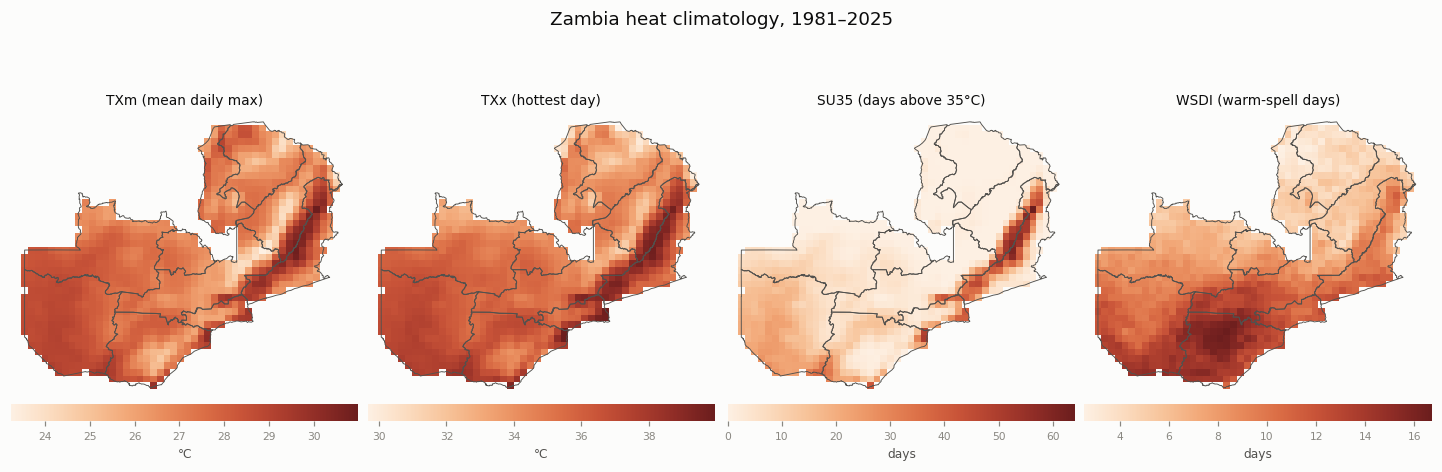

In [7]:
# ---- Figure 1: heat climatology. Magnitude -> ONE hue, light to dark ----------
show = ["txm", "txx", "su35", "wsdi"]
fig, axes = plt.subplots(1, 4, figsize=(13, 3.9), constrained_layout=True)
for ax, idx in zip(axes, show):
    m = ax.pcolormesh(LON_E, LAT_E, clim[idx], cmap=SEQ_WARM, shading="flat")
    basemap(ax); ax.set_title(LAB[idx], color=INK, pad=6, fontsize=9)
    cb = fig.colorbar(m, ax=ax, orientation="horizontal", pad=.02, fraction=.05)
    cb.set_label(UNIT[idx], color=INK2, fontsize=8)
    cb.ax.tick_params(labelsize=7, colors=MUTED); cb.outline.set_visible(False)
fig.suptitle("Zambia heat climatology, 1981–2025", color=INK, fontsize=12, y=1.06)
fig.savefig(os.path.join(FIGDIR, "fig1_climatology.png"), bbox_inches="tight")
plt.show()

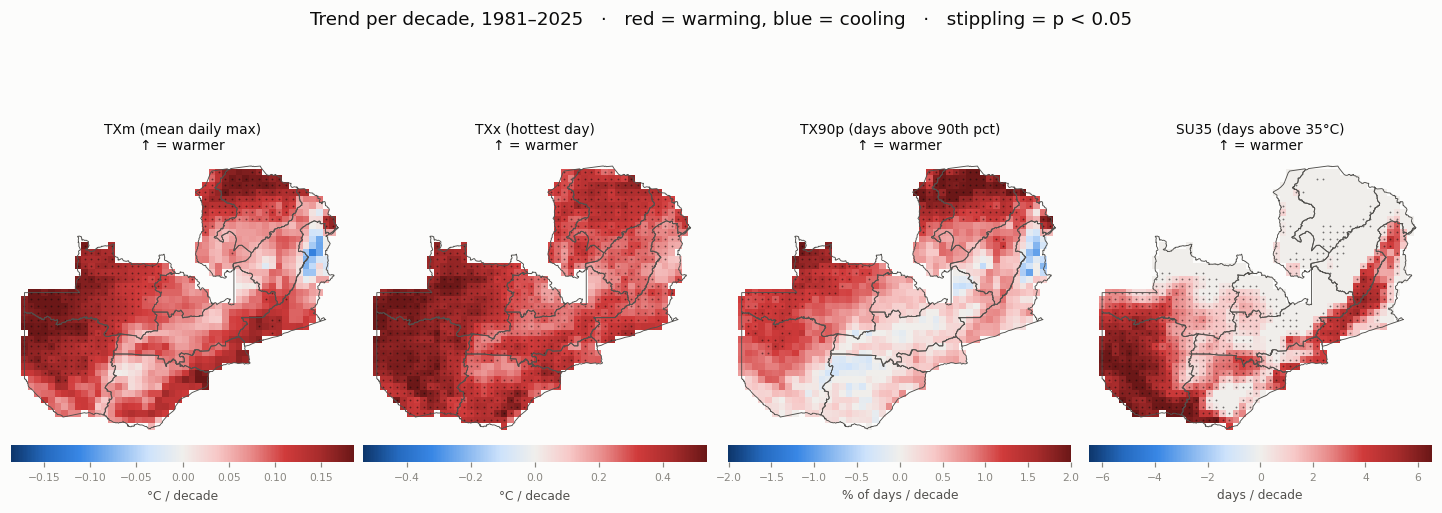

In [8]:
# ---- Figure 2: trends. Polarity -> diverging with a NEUTRAL GRAY midpoint -----
show = ["txm", "txx", "tx90p", "su35"]
fig, axes = plt.subplots(1, 4, figsize=(13, 4.1), constrained_layout=True)
for ax, idx in zip(axes, show):
    d = gtrend[idx]
    lim = np.nanpercentile(np.abs(d), 98) or 1.0
    m = ax.pcolormesh(LON_E, LAT_E, d, cmap=DIV_RB, shading="flat", vmin=-lim, vmax=lim)
    yy, xx = np.where(gp[idx] < .05)
    if len(yy):
        ax.scatter(lon[xx], lat[yy], s=1.4, c="#0b0b0b", alpha=.55, linewidths=0, zorder=4)
    basemap(ax); ax.set_title(f"{LAB[idx]}\n↑ = warmer", color=INK, pad=6, fontsize=9)
    cb = fig.colorbar(m, ax=ax, orientation="horizontal", pad=.02, fraction=.05)
    cb.set_label(f"{UNIT[idx]} / decade", color=INK2, fontsize=8)
    cb.ax.tick_params(labelsize=7, colors=MUTED); cb.outline.set_visible(False)
fig.suptitle("Trend per decade, 1981–2025   ·   red = warming, blue = cooling"
             "   ·   stippling = p < 0.05", color=INK, fontsize=12, y=1.10)
fig.savefig(os.path.join(FIGDIR, "fig2_trend_maps.png"), bbox_inches="tight")
plt.show()

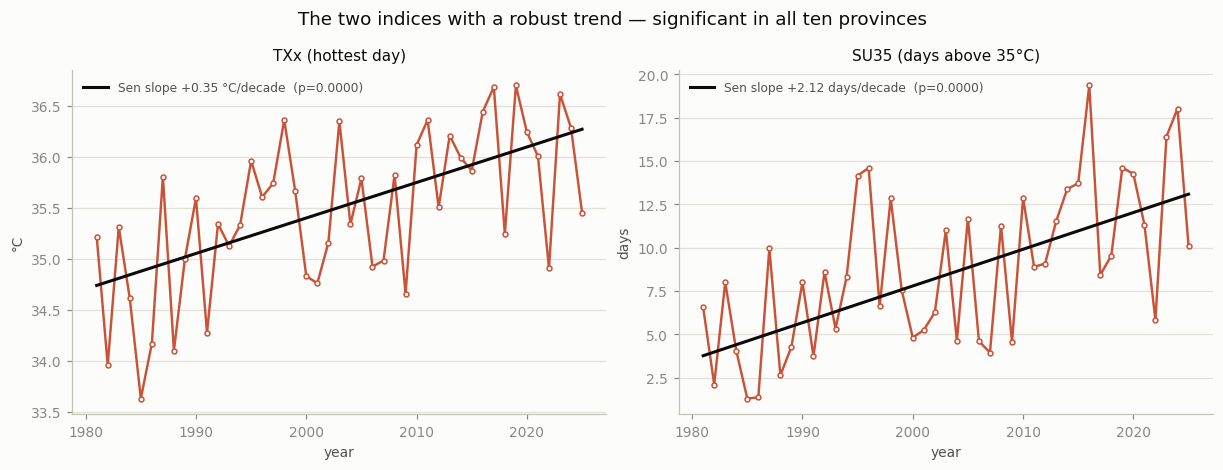

In [9]:
# ---- Figure 3: the two robust indices, national series -----------------------
nat_s = ann[ann.region == "Zambia"].pivot(index="year", columns="index", values="value").sort_index()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
for ax, idx in zip(axes, ["txx", "su35"]):
    y = nat_s[idx].values
    ax.plot(years, y, lw=1.6, color="#c85338", marker="o", ms=3.2,
            mfc=SURFACE, mew=1.0, mec="#c85338")
    row = t_ann[(t_ann.region == "Zambia") & (t_ann["index"] == idx)].iloc[0]
    fit = np.median(y) + row.trend_per_decade/10 * (years - np.median(years))
    ax.plot(years, fit, lw=2, color=INK,
            label=f"Sen slope {row.trend_per_decade:+.2f} {row.units}/decade  (p={row.p:.4f})")
    ax.legend(frameon=False, fontsize=8, loc="upper left", labelcolor=INK2)
    ax.set_title(LAB[idx], color=INK); ax.set_ylabel(row.units, color=INK2)
    ax.set_xlabel("year", color=INK2); ax.yaxis.grid(True); ax.set_axisbelow(True)
fig.suptitle("The two indices with a robust trend — significant in all ten provinces",
             color=INK, fontsize=12, y=1.08)
fig.savefig(os.path.join(FIGDIR, "fig3_national_series.png"), bbox_inches="tight")
plt.show()

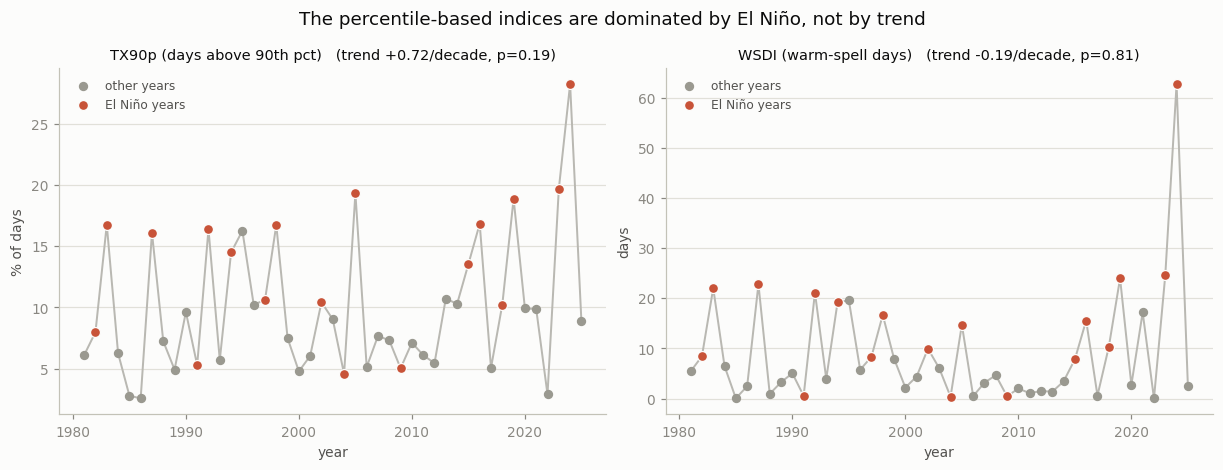

9 of the 10 warmest years by TX90p coincide with an El Niño event.
TX90p and WSDI correlate at r = 0.89, and WSDI's skew is 2.80 (range 0.02–62.7 days).


In [10]:
# ---- Figure 4: why TX90p and WSDI show no trend — ENSO --------------------------
# Major El Nino years (NOAA ONI, DJF-peaking events labelled by the calendar year in
# which the Zambian hot season falls).
ELNINO = {1982,1983,1987,1991,1992,1994,1997,1998,2002,2004,2005,2009,2015,2016,2018,2019,2023,2024}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
for ax, idx in zip(axes, ["tx90p", "wsdi"]):
    y = nat_s[idx].values
    en = np.array([yr in ELNINO for yr in years.astype(int)])
    ax.plot(years, y, lw=1.3, color="#b9b8b2", zorder=1)
    ax.scatter(years[~en], y[~en], s=26, color="#9a9990", zorder=3, label="other years")
    ax.scatter(years[en], y[en], s=42, color="#c85338", zorder=4,
               edgecolor=SURFACE, linewidth=.8, label="El Niño years")
    row = t_ann[(t_ann.region == "Zambia") & (t_ann["index"] == idx)].iloc[0]
    ax.set_title(f"{LAB[idx]}   (trend {row.trend_per_decade:+.2f}/decade, p={row.p:.2f})",
                 color=INK, fontsize=9.5)
    ax.set_ylabel(row.units, color=INK2); ax.set_xlabel("year", color=INK2)
    ax.legend(frameon=False, fontsize=8, labelcolor=INK2)
    ax.yaxis.grid(True); ax.set_axisbelow(True)
fig.suptitle("The percentile-based indices are dominated by El Niño, not by trend",
             color=INK, fontsize=12, y=1.08)
fig.savefig(os.path.join(FIGDIR, "fig4_enso.png"), bbox_inches="tight")
plt.show()

top = nat_s.tx90p.sort_values(ascending=False).head(10).index.astype(int)
hits = sum(1 for y in top if y in ELNINO)
print(f"{hits} of the 10 warmest years by TX90p coincide with an El Niño event.")
print(f"TX90p and WSDI correlate at r = {nat_s.tx90p.corr(nat_s.wsdi):.2f}, and WSDI's "
      f"skew is {nat_s.wsdi.skew():.2f} (range {nat_s.wsdi.min():.2f}–{nat_s.wsdi.max():.1f} days).")

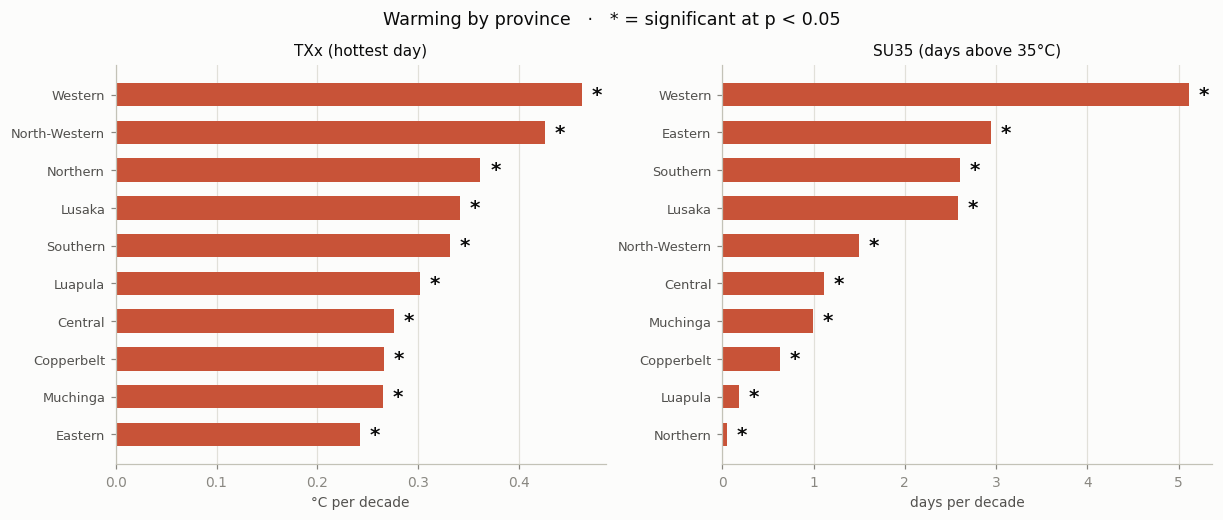

In [11]:
# ---- Figure 5: province trends for the two robust indices --------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), constrained_layout=True)
for ax, idx in zip(axes, ["txx", "su35"]):
    t = (t_ann[(t_ann["index"] == idx) & (t_ann.region != "Zambia")]
         .sort_values("trend_per_decade"))
    y = np.arange(len(t))
    ax.barh(y, t.trend_per_decade, color="#c85338", height=.62)
    ax.set_yticks(y); ax.set_yticklabels(t.region, fontsize=8.5, color=INK2)
    ax.axvline(0, color=AXIS, lw=1)
    for k, s in enumerate(t.sig05):
        if s:
            v = t.trend_per_decade.iloc[k]
            ax.text(v + .02*abs(ax.get_xlim()[1]), k, "*", va="center",
                    color=INK, fontsize=13, fontweight="bold")
    ax.set_xlabel(f"{t.units.iloc[0]} per decade", color=INK2)
    ax.set_title(LAB[idx], color=INK); ax.xaxis.grid(True); ax.set_axisbelow(True)
fig.suptitle("Warming by province   ·   * = significant at p < 0.05",
             color=INK, fontsize=11.5, y=1.06)
fig.savefig(os.path.join(FIGDIR, "fig5_province_trends.png"), bbox_inches="tight")
plt.show()

## Findings

In [12]:
print("NATIONAL, ANNUAL  (1981-2025)")
print("-" * 88)
for idx in IDX:
    r = t_ann[(t_ann.region == "Zambia") & (t_ann["index"] == idx)].iloc[0]
    v = "SIGNIFICANT" if r.p < 0.05 else ("marginal" if r.p < 0.10 else "not significant")
    prov = t_ann[(t_ann["index"] == idx) & (t_ann.region != "Zambia")]
    print(f"  {LAB[idx]:<32}{r.trend_per_decade:+8.3f} {r.units:<10} p={r.p:7.4f}  "
          f"{v:<16} [{int(prov.sig05.sum())}/10 provinces]")

# The rainfall figures below are quoted from the companion study rather than recomputed,
# since that dataset lives in a separate repository:
#   https://github.com/nephatmwanza/zambia-rainfall-extremes
print("\nCONTRAST WITH THE RAINFALL ANALYSIS (same country, period, baseline and method)")
print("-" * 88)
print(f"  heat     : {int(t_ann.sig05.sum())}/{len(t_ann)} region-index trends significant at p<0.05")
print(f"  rainfall :  4/88 region-index trends significant at p<0.05   [companion study]")
print("  no rainfall grid cell survived FDR control for ANY index;")
print("  here 987 cells survive for TXx and 720 for SU35.")
print("  => the pipeline detects trends when they exist, so the rainfall null is a real")
print("     absence of signal rather than a weak test.")

NATIONAL, ANNUAL  (1981-2025)
----------------------------------------------------------------------------------------
  TXm (mean daily max)              +0.113 °C         p= 0.0390  SIGNIFICANT      [4/10 provinces]
  TXx (hottest day)                 +0.348 °C         p= 0.0000  SIGNIFICANT      [10/10 provinces]
  TX90p (days above 90th pct)       +0.724 % of days  p= 0.1866  not significant  [2/10 provinces]
  SU35 (days above 35°C)            +2.118 days       p= 0.0000  SIGNIFICANT      [10/10 provinces]
  WSDI (warm-spell days)            -0.186 days       p= 0.8068  not significant  [0/10 provinces]

CONTRAST WITH THE RAINFALL ANALYSIS (same country, period, baseline and method)
----------------------------------------------------------------------------------------
  heat     : 29/55 region-index trends significant at p<0.05
  rainfall :  4/88 region-index trends significant at p<0.05   [companion study]
  no rainfall grid cell survived FDR control for ANY index;
  here 987 c

### Reading these results

**Temperature gives the clear answer that rainfall did not.** The hottest day of the year
(TXx) and the count of days above 35 °C (SU35) are rising in **all ten provinces**, and
significantly so in every one of them. The rainfall analysis, run identically, produced no
grid cell that survived false-discovery-rate control for any index. This is the expected
physical picture — thermodynamic signals emerge from natural variability faster than the
dynamic circulation changes that govern rainfall — but it is worth having demonstrated on the
same data rather than asserted.

**The two percentile-based indices are a different case, and it is not a failure.** TX90p and
WSDI show no significant trend because they are dominated by El Niño: nine of the ten warmest
years coincide with an event, and they correlate with each other at r ≈ 0.89. WSDI in
particular is extremely skewed — most years near zero, occasional spikes above 60 days. A
median-based estimator like Theil–Sen correctly refuses to read a trend into that, even
though the *mean* rises. Reporting "no trend" here is the honest result, and the ENSO
structure is itself the finding.

**What this means together with the rainfall work.** Planning that assumes a clear directional
rainfall signal is not supported by the record. Planning for **more heat** is — and heat
interacts with the growing-season dry spells identified in the rainfall analysis, since crop
water demand rises exactly when a longer dry spell would bite.

Outputs written by this notebook:

- `data/processed/trends_heat_annual_by_province.csv`, `…_ondjfm_by_province.csv`
- `figures/fig6…fig10*.png`